<a href="https://colab.research.google.com/github/zmzain/zmzain/blob/main/AraELECTRA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
import seaborn as sns
import matplotlib.pyplot as plt
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, EarlyStoppingCallback


In [2]:
# --- Config ---
CSV_PATH = "https://raw.githubusercontent.com/zmzain/zmzain/89462097da8cf598cf5e1ddfc2853c4a088f3d49/data1.csv"
TEXT_COL = "Text"
LABEL_COL = "class"
# Switched to AraELECTRA for fairness comparison
MODEL_NAME = "aubmindlab/araelectra-base-discriminator"
MAX_LENGTH = 256
BATCH_SIZE = 16
EVAL_BATCH = 32
LR = 2e-5
EPOCHS = 8
OUTPUT_DIR = "./araelectra_train"
EARLY_STOPPING_PATIENCE = 2
SEED = 42


In [3]:
# --- Load data ---
df = pd.read_csv(CSV_PATH)

# map labels to ints
if df[LABEL_COL].dtype == object:
    labels_list = sorted(df[LABEL_COL].unique())
    label2id = {l: i for i, l in enumerate(labels_list)}
    id2label = {i: l for l, i in label2id.items()}
    df["label_id"] = df[LABEL_COL].map(label2id)
else:
    df["label_id"] = df[LABEL_COL].astype(int)
    labels_list = sorted(df["label_id"].unique())
    id2label = {i: str(i) for i in labels_list}
    label2id = {v: v for v in labels_list}

n_labels = len(label2id)


In [4]:
# --- Splits (Consistent with previous pipelines) ---
train_df, test_df = train_test_split(df, test_size=0.2, stratify=df["label_id"], random_state=SEED)
train_df, val_df = train_test_split(train_df, test_size=0.125, stratify=train_df["label_id"], random_state=SEED)


In [5]:
# --- Tokenizer ---
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def to_hf_dataset(df_sub):
    enc = tokenizer(list(df_sub[TEXT_COL].astype(str).values),
                    truncation=True, padding="max_length", max_length=MAX_LENGTH)
    enc["labels"] = list(df_sub["label_id"].values)
    return Dataset.from_dict(enc)

train_ds = to_hf_dataset(train_df)
val_ds = to_hf_dataset(val_df)
test_ds = to_hf_dataset(test_df)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/503 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/392 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [6]:
# --- Class weights ---
y_train = train_df["label_id"].values
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weights = torch.tensor(class_weights, dtype=torch.float)


In [7]:
# --- Model ---
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=n_labels)


model.safetensors:   0%|          | 0.00/541M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

ElectraForSequenceClassification LOAD REPORT from: aubmindlab/araelectra-base-discriminator
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
electra.embeddings.position_ids                   | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense.bias              | UNEXPECTED | 
classifier.out_proj.bias                          | MISSING    | 
classifier.dense.bias                             | MISSING    | 
classifier.out_proj.weight                        | MISSING    | 
classifier.dense.weight                           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missin

In [8]:
# --- Custom Trainer to use class weights in loss ---
class WeightedTrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights.to(self.model.device) if class_weights is not None else None

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.get("labels")
        # forward (without labels) to get logits
        outputs = model(**{k: v for k, v in inputs.items() if k != "labels"})
        logits = outputs.logits
        loss_fct = torch.nn.CrossEntropyLoss(weight=self.class_weights)
        loss = loss_fct(logits.view(-1, model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss


In [9]:
# --- Metrics (sklearn) ---
def compute_metrics(p):
    preds = np.argmax(p.predictions, axis=1)
    labels = p.label_ids
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average="macro", zero_division=0)
    return {"macro_precision": precision, "macro_recall": recall, "macro_f1": f1}


In [10]:
# --- Training args and trainer ---
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=LR,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=EVAL_BATCH,
    num_train_epochs=EPOCHS,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    logging_steps=50,
    save_total_limit=3,
    seed=SEED,
    fp16=torch.cuda.is_available()
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=EARLY_STOPPING_PATIENCE)],
    class_weights=class_weights
)


In [11]:
# --- Train ---
trainer.train()


Epoch,Training Loss,Validation Loss,Macro Precision,Macro Recall,Macro F1
1,0.483200,0.520153,0.776886,0.813259,0.776245
2,0.359526,0.465083,0.836473,0.839428,0.835735
3,0.236043,0.634230,0.825605,0.809666,0.814751
4,0.224347,0.768785,0.844872,0.826572,0.834530


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['electra.embeddings.LayerNorm.weight', 'electra.embeddings.LayerNorm.bias', 'electra.encoder.layer.0.attention.output.LayerNorm.weight', 'electra.encoder.layer.0.attention.output.LayerNorm.bias', 'electra.encoder.layer.0.output.LayerNorm.weight', 'electra.encoder.layer.0.output.LayerNorm.bias', 'electra.encoder.layer.1.attention.output.LayerNorm.weight', 'electra.encoder.layer.1.attention.output.LayerNorm.bias', 'electra.encoder.layer.1.output.LayerNorm.weight', 'electra.encoder.layer.1.output.LayerNorm.bias', 'electra.encoder.layer.2.attention.output.LayerNorm.weight', 'electra.encoder.layer.2.attention.output.LayerNorm.bias', 'electra.encoder.layer.2.output.LayerNorm.weight', 'electra.encoder.layer.2.output.LayerNorm.bias', 'electra.encoder.layer.3.attention.output.LayerNorm.weight', 'electra.encoder.layer.3.attention.output.LayerNorm.bias', 'electra.encoder.layer.3.output.LayerNorm.weight', 'electra.encoder.layer.3.output.Laye

TrainOutput(global_step=4032, training_loss=0.3404439219406673, metrics={'train_runtime': 963.7263, 'train_samples_per_second': 133.872, 'train_steps_per_second': 8.368, 'total_flos': 8486460175398912.0, 'train_loss': 0.3404439219406673, 'epoch': 4.0})

In [12]:
# --- Test evaluation ---
pred_out = trainer.predict(test_ds)
y_pred = np.argmax(pred_out.predictions, axis=1)
y_true = pred_out.label_ids


In [13]:
# --- Print classification report and macro scores ---
print("Classification Report (AraELECTRA):")
print(classification_report(y_true, y_pred, target_names=[id2label[i] for i in range(n_labels)], zero_division=0))
p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
print(f"Macro Precision: {p:.4f}")
print(f"Macro Recall:    {r:.4f}")
print(f"Macro F1-score:  {f1:.4f}")


Classification Report (AraELECTRA):
              precision    recall  f1-score   support

    negative       0.81      0.90      0.85      1836
     neutral       0.89      0.79      0.84      2039
    positive       0.75      0.80      0.77       733

    accuracy                           0.83      4608
   macro avg       0.82      0.83      0.82      4608
weighted avg       0.84      0.83      0.83      4608

Macro Precision: 0.8188
Macro Recall:    0.8283
Macro F1-score:  0.8214


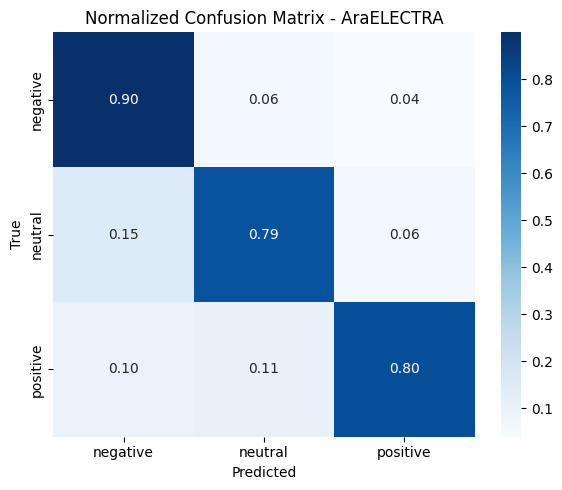

In [14]:
# --- Normalized confusion matrix (rows=true, cols=pred) ---
cm = confusion_matrix(y_true, y_pred, labels=np.arange(n_labels))
row_sums = cm.sum(axis=1, keepdims=True)
cm_norm = np.divide(cm, row_sums, where=(row_sums != 0))
plt.figure(figsize=(max(6, n_labels), max(5, n_labels*0.5)))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=[id2label[i] for i in range(n_labels)],
            yticklabels=[id2label[i] for i in range(n_labels)])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Normalized Confusion Matrix - AraELECTRA")
plt.tight_layout()
plt.show()
